In [ ]:
!pip install datasets transformers accelerate torch torchvision scikit-learn matplotlib wandb

In [ ]:
import json

input_file = "Fine_tuning_a_Vision_Transformer_Model_With_a_Custom_Biomedical_Dataset.ipynb"
output_file = "fixed_notebook.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# Remove widget metadata
if "widgets" in data.get("metadata", {}):
    del data["metadata"]["widgets"]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

print("Notebook fixed and saved as:", output_file)

# DataSet Preprocessing

In [ ]:
from datasets import load_dataset as ld

dataset =ld("emre570/breastcancer-ultrasound-images")
dataset

In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 156
    })
})

**Create the validation set because don’t have a validation set.**

In [3]:
# Get the numbers of each set
test =len(dataset["test"])
train =len(dataset['train'])
train, test

val_set =test /train
val_set

0.25

In [4]:
train_val_split =dataset['train'].train_test_split(test_size=val_set)
train_val_split

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 468
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 156
    })
})

In [5]:
#We got our seperated train set. Let’s merge them with test set
from datasets import DatasetDict

dataset =DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'],
    'test': dataset['test'],
})

In [6]:
train_ds =dataset["train"]
val_ds =dataset["validation"]
test_ds =dataset["test"]

train_ds, val_ds, test_ds

(Dataset({
     features: ['image', 'label'],
     num_rows: 468
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 156
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 156
 }))

In [7]:
train_ds[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=560x467>,
 'label': 0}

In [ ]:
train_ds.features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['benign', 'malignant', 'normal'])}

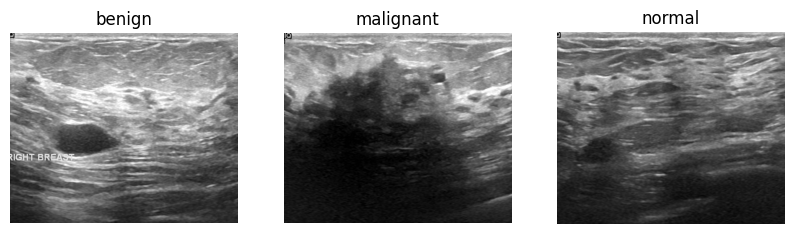

In [8]:
import matplotlib.pyplot as plt

# Initialize a set to keep track of shown labels
shown_labels = set()

# Initialize the figure for plotting
plt.figure(figsize=(10, 10))

# Loop through the dataset and plot the first image of each label
for i, sample in enumerate(train_ds):
    label = train_ds.features['label'].names[sample['label']]
    if label not in shown_labels:
        plt.subplot(1, len(train_ds.features['label'].names), len(shown_labels) + 1)
        plt.imshow(sample['image'])
        plt.title(label)
        plt.axis('off')
        shown_labels.add(label)
        if len(shown_labels) == len(train_ds.features['label'].names):
            break

plt.show()

# Data Preprocessing

## Label Mapping

In [9]:
#Label Mapping

id2label = {id:label for id, label in enumerate(train_ds.features['label'].names)}
label2id = {label:id for id,label in id2label.items()}
label2id


{'benign': 0, 'malignant': 1, 'normal': 2}

In [ ]:
id2label

{0: 'benign', 1: 'malignant', 2: 'normal'}

In [ ]:
id2label, id2label[train_ds[2]['label']]

({0: 'benign', 1: 'malignant', 2: 'normal'}, 'benign')

## Image Processing

In [ ]:
# Image processing
from transformers import ViTImageProcessor

model_name = "google/vit-large-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)


In [11]:
processor

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [12]:
from torchvision.transforms import CenterCrop, Compose, Normalize, RandomHorizontalFlip, RandomResizedCrop, ToTensor, Resize

# Get model image parameters
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]
size

224

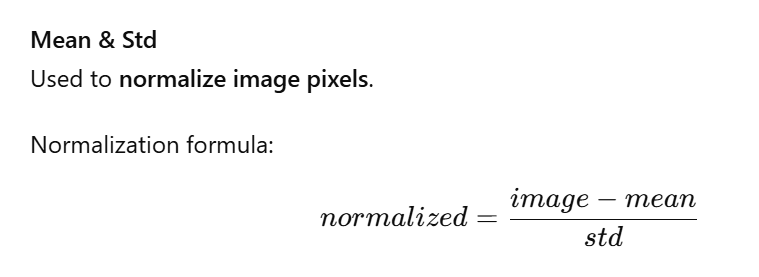

In [13]:
normalize = Normalize(mean=image_mean,std=image_std)
normalize

Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

1️⃣ RandomResizedCrop(size)

Randomly crops part of the image

Resizes it to model input size

Helps model learn from different views

2️⃣ RandomHorizontalFlip()

Randomly flips image horizontally with 50% probability.

In [14]:
train_transforms = Compose([
    RandomResizedCrop(size), #[Original: 512x512 --> Random crop → 224x224]
    RandomHorizontalFlip(), # Original -> Mirrored Image [Helps model learn orientation variations.]
    ToTensor(), #PIL Image → PyTorch Tensor [0-255 →between 0-1]
    normalize, #Normalizes tensor using mean and std.
])
train_transforms

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

In [15]:
#Validation must be deterministic (no randomness).
val_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize, #Normalize pixel values.
])
val_transforms


Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

Same as validation.

Why?  
Test data should not use augmentation because we want true performance measurement.

In [16]:

test_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

## Create transform functions

In [17]:
def apply_train_transforms(examples):
    #Creates a new column in the dataset called: pixel_values [this is the processed image tensor that will be fed into the model.]
    examples['pixel_values'] = [train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples
#pixel_values → Tensor (C × H × W)
def apply_val_transforms(examples):
    examples['pixel_values'] = [val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

def apply_test_transforms(examples):
    examples['pixel_values'] = [test_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

## Apply transform functions to each set

In [18]:
train_ds.set_transform(apply_train_transforms)
val_ds.set_transform(apply_val_transforms)
test_ds.set_transform(apply_test_transforms)

In [19]:
train_ds.features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['benign', 'malignant', 'normal'])}

In [20]:
train_ds[1]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=886x581>,
 'label': 0,
 'pixel_values': tensor([[[-0.1373, -0.1294, -0.1137,  ..., -0.1294, -0.0510,  0.0118],
          [-0.1294, -0.0980, -0.0824,  ..., -0.1608, -0.1294, -0.0980],
          [-0.0667, -0.0667, -0.0667,  ..., -0.1608, -0.1529, -0.1843],
          ...,
          [-0.6392, -0.6314, -0.6000,  ..., -0.8902, -0.8980, -0.9137],
          [-0.6314, -0.6078, -0.5922,  ..., -0.9216, -0.9137, -0.9137],
          [-0.6235, -0.6078, -0.6078,  ..., -0.9137, -0.8902, -0.8824]],
 
         [[-0.1373, -0.1294, -0.1137,  ..., -0.1294, -0.0510,  0.0118],
          [-0.1294, -0.0980, -0.0824,  ..., -0.1608, -0.1294, -0.0980],
          [-0.0667, -0.0667, -0.0667,  ..., -0.1608, -0.1529, -0.1843],
          ...,
          [-0.6392, -0.6314, -0.6000,  ..., -0.8902, -0.8980, -0.9137],
          [-0.6314, -0.6078, -0.5922,  ..., -0.9216, -0.9137, -0.9137],
          [-0.6235, -0.6078, -0.6078,  ..., -0.9137, -0.8902, -0.8824]],


## Data Loading

In [21]:
from torch.utils.data import DataLoader
import torch
# Custom function to combine dataset samples into a batch
def collate_fn(examples):

    # Stack image tensors into a single batch tensor
    # Converts list of tensors (3x224x224) → tensor (batch_size,3,224,224)
    pixel_values = torch.stack([example["pixel_values"] for example in examples])

    # Extract labels and convert them into a tensor
    labels = torch.tensor([example["label"] for example in examples])

    # Return batch dictionary used as model input
    return {"pixel_values": pixel_values, "labels": labels}

# Create DataLoader to load training data in batches
train_dl = DataLoader(
    train_ds,              # training dataset
    collate_fn=collate_fn, # custom batch creation function
    batch_size=4           # number of samples per batch [Batch 1 → images 1-4]
)

In [22]:
#shapes of tensors.
batch = next(iter(train_dl))
# Get the first batch from the DataLoader
batch = next(iter(train_dl))

# Loop through each key-value pair in the batch dictionary
for k, v in batch.items():

    # Check if the value is a PyTorch tensor
    if isinstance(v, torch.Tensor):

        # Print the key name and tensor shape
        print(k, v.shape)

pixel_values torch.Size([4, 3, 224, 224])
labels torch.Size([4])


In [23]:
batch = next(iter(train_dl))
print(batch)

{'pixel_values': tensor([[[[ 0.5373,  0.5686,  0.5686,  ...,  0.9373,  0.8353,  0.7333],
          [ 0.1843,  0.1843,  0.1922,  ...,  0.5216,  0.4902,  0.4510],
          [ 0.0510,  0.0431,  0.0510,  ..., -0.0118,  0.0118,  0.0353],
          ...,
          [-0.6706, -0.6784, -0.6863,  ..., -0.3725, -0.3961, -0.4353],
          [-0.6235, -0.6235, -0.6235,  ..., -0.3255, -0.3255, -0.3490],
          [-0.6627, -0.6471, -0.6235,  ..., -0.3333, -0.3098, -0.3020]],

         [[ 0.5373,  0.5686,  0.5686,  ...,  0.9373,  0.8353,  0.7333],
          [ 0.1843,  0.1843,  0.1922,  ...,  0.5216,  0.4902,  0.4510],
          [ 0.0510,  0.0431,  0.0510,  ..., -0.0118,  0.0118,  0.0353],
          ...,
          [-0.6706, -0.6784, -0.6863,  ..., -0.3725, -0.3961, -0.4353],
          [-0.6235, -0.6235, -0.6235,  ..., -0.3255, -0.3255, -0.3490],
          [-0.6627, -0.6471, -0.6235,  ..., -0.3333, -0.3098, -0.3020]],

         [[ 0.5373,  0.5686,  0.5686,  ...,  0.9373,  0.8353,  0.7333],
          [ 0

# Fine-tuning the Model

In [24]:
import base64
from IPython.display import Image, display

def render_mermaid(graph_code):
    graphbytes = graph_code.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    # Using mermaid.ink to generate a high-quality PNG
    url = "https://mermaid.ink/img/" + base64_string
    display(Image(url=url))

# Your PyTorch Data Pipeline Code
pipeline_graph = """
graph TD
    A[(Dataset)] -->|Index Access| B(Single Sample)

    subgraph Data_Loading_Process [Batching Logic]
    B -->|Collects 4 Samples| C{DataLoader}
    C -->|List of Samples| D[collate_fn]
    D -->|torch.stack| E(Batch Output)
    end

    E -->|Forward Pass| F[[Model Training]]

    %% Content Details
    B --- B_text["pixel_values: tensor(3,224,224)<br/>label: 1"]
    E --- E_text["pixel_values: tensor(4,3,224,224)<br/>labels: tensor(4)"]

    style A fill:#f9f,stroke:#333
    style E fill:#bbf,stroke:#333
    style F fill:#dfd,stroke:#333,stroke-width:4px
"""

render_mermaid(pipeline_graph)


In [ ]:
# Import Vision Transformer model for image classification
from transformers import ViTForImageClassification

# Load pretrained Vision Transformer model
model = ViTForImageClassification.from_pretrained(

    model_name,                 # Name of pretrained model from HuggingFace Hub

    id2label=id2label,          # Mapping from class ID to class name

    label2id=label2id,          # Mapping from class name to class ID

    ignore_mismatched_sizes=True # Allows replacing the classification layer if number of classes differs
)

In [44]:
# optional
# It tells the Trainer how the model should train, evaluate, log results, and save checkpoints.
from transformers import TrainingArguments, Trainer
import numpy as np

# Define training configuration for the HuggingFace Trainer
train_args = TrainingArguments(

    output_dir="output-models",          # Directory where trained models and checkpoints will be saved

    save_total_limit=2,                  # Maximum number of checkpoints to keep (older ones deleted)

    report_to="wandb",                   # Send training metrics to Weights & Biases dashboard

    save_strategy="epoch",               # Save model after each training epoch

    eval_strategy="epoch",         # Run evaluation on validation set after each epoch

    logging_strategy="steps",   # enable logging
    logging_steps=2,           # log every 10 steps

    learning_rate=2e-5,                  # Learning rate for optimizer (very common for transformers)

    per_device_train_batch_size=10,      # Number of samples processed per device during training

    per_device_eval_batch_size=4,        # Batch size used during evaluation

    num_train_epochs=5,                 # Total number of training epochs

    weight_decay=0.01,                   # Regularization term to prevent overfitting

    load_best_model_at_end=True,         # After training, load the model with best evaluation performance

    logging_dir='logs',                  # Directory where training logs will be stored

    remove_unused_columns=False,         # Prevent Trainer from removing dataset columns (important for vision tasks)
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [45]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
"""
Internally, HuggingFace runs something similar to this loop:
for epoch in range(num_epochs):

    for batch in train_dataset:

        outputs = model(pixel_values=batch["pixel_values"])

        loss = compute_loss(outputs, labels)

        loss.backward()

        optimizer.step()

        scheduler.step()

    evaluate(validation_dataset)

    save_checkpoint()
"""

trainer = Trainer(

    model,                     # Vision Transformer model to train

    train_args,                # Training configuration (epochs, learning rate, batch size)

    train_dataset=train_ds,    # Dataset used for training

    eval_dataset=val_ds,       # Dataset used for validation during training

    data_collator=collate_fn,  # Function that creates batches from dataset samples

    #compute_metrics=compute_metrics        # Image processor used for preprocessing and saving configuration
)

# Start model training
trainer.train()

In [47]:
outputs = trainer.predict(test_ds)
print(outputs.metrics)

{'test_loss': 0.5071985125541687, 'test_runtime': 9.4601, 'test_samples_per_second': 16.49, 'test_steps_per_second': 4.123}


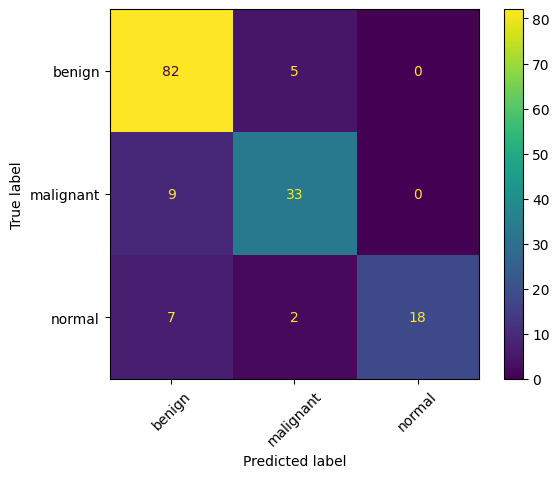

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = train_ds.features['label'].names
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)

In [49]:
from sklearn.metrics import recall_score,classification_report

# Calculate the recall scores
# 'None' calculates recall for each class separately
recall = recall_score(y_true, y_pred, average=None)
report =classification_report(y_true,y_pred)

print(report)

# Print the recall for each class
for label, score in zip(labels, recall):
    print(f'Recall for {label}: {score:.2f}')

              precision    recall  f1-score   support

           0       0.84      0.94      0.89        87
           1       0.82      0.79      0.80        42
           2       1.00      0.67      0.80        27

    accuracy                           0.85       156
   macro avg       0.89      0.80      0.83       156
weighted avg       0.86      0.85      0.85       156

Recall for benign: 0.94
Recall for malignant: 0.79
Recall for normal: 0.67


# I test it on small epoch, u can increase it upto 50 and also other techniques